# 3.2 Collision Geometry

Ellipsoidal obstacles with Omega collision matrix.

Box [0.5 0.6 1.7] -> axes [0.433 0.52  1.472], corner val=1.000000 (should be 1.0)


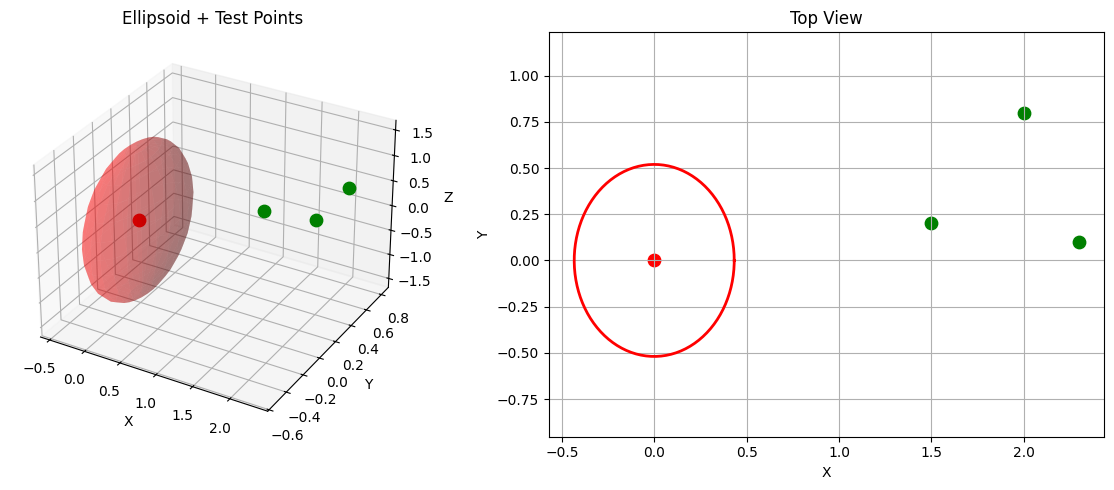

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, sqrt
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

def box_to_ellipsoid(size):
    return 0.5*sqrt(3.0)*np.array(size)

size = np.array([0.5, 0.6, 1.7])
axes = box_to_ellipsoid(size)
corner = size/2
val = sum((corner[i]/axes[i])**2 for i in range(3))
print("Box %s -> axes %s, corner val=%.6f (should be 1.0)" % (str(size), str(axes.round(3)), val))
assert abs(val-1.0) < 1e-10

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
u = np.linspace(0, 2*np.pi, 25); v = np.linspace(0, np.pi, 15)
xe = axes[0]*np.outer(np.cos(u), np.sin(v))
ye = axes[1]*np.outer(np.sin(u), np.sin(v))
ze = axes[2]*np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xe, ye, ze, color='red', alpha=0.3)
for p,c in [([0,0,0],'green'),([1.5,0.2,0.5],'green'),([2.3,0.1,0.8],'red'),([2,0.8,0.3],'red')]:
    coll = (p[0]/axes[0])**2+(p[1]/axes[1])**2+(p[2]/axes[2])**2<=1
    ax.scatter(*p,c='red' if coll else 'green',s=80)
ax.set_xlabel('X');ax.set_ylabel('Y');ax.set_zlabel('Z');ax.set_title('Ellipsoid + Test Points')

ax2 = fig.add_subplot(122)
theta = np.linspace(0,2*np.pi,200)
ax2.plot(axes[0]*np.cos(theta), axes[1]*np.sin(theta),'r-',lw=2)
for p in [[0,0],[1.5,0.2],[2.3,0.1],[2,0.8]]:
    coll = (p[0]/axes[0])**2+(p[1]/axes[1])**2<=1
    ax2.scatter(*p,c='red' if coll else 'green',s=80)
ax2.set_xlabel('X');ax2.set_ylabel('Y');ax2.axis('equal');ax2.grid(True);ax2.set_title('Top View')
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/3.2_collision.png', dpi=100, bbox_inches='tight')
plt.show()


# Summary

Box->ellipsoid: (a,b,c) = sqrt(3)/2 * (l,w,h). Collision via Omega matrix.